In [80]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import cv2
from tensorflow.keras.preprocessing import image


In [ ]:
# Load class names
with open('class_names.json', 'r', encoding='utf-8') as f:
    class_names = json.load(f)

# Load the multi-output model
model = tf.keras.models.load_model(
    'acne_model_final .keras', 
    custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)
print('Model loaded successfully!')


Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step


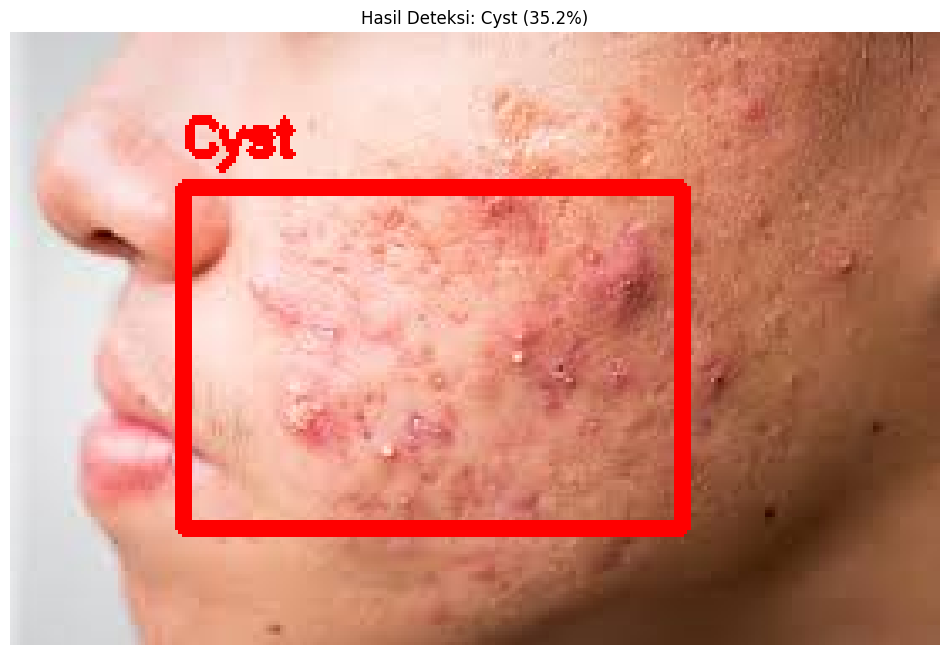

--- Statistik Prediksi ---
Blackheads: 1.20%
Cyst: 35.15%
Papules: 22.46%
Pustules: 31.55%
Whiteheads: 0.03%
darkspots: 9.61%


In [82]:
# Path ke gambar
img_path = 'images.jpg'
IMAGE_SIZE = 160

# 1. Load dan preprocessing (Gambar asli tetap RGB)
img_raw = image.load_img(img_path)
img_original = image.img_to_array(img_raw).astype(np.uint8)
img_resized = cv2.resize(img_original, (IMAGE_SIZE, IMAGE_SIZE))
img_array = np.expand_dims(img_resized, axis=0)

# 2. Prediksi
predictions = model.predict(img_array)
top_class_idx = np.argmax(predictions[0])
top_class_name = class_names[top_class_idx]
top_class_prob = predictions[0][top_class_idx] * 100

# 3. Grad-CAM Logic (Manual Reconstruction)
def get_gradcam_roi(model, img_array, pred_index):
    base_model = model.get_layer('mobilenetv2_1.00_160')
    last_conv_layer = base_model.get_layer('out_relu')
    inputs = base_model.input
    x = base_model.output
    x = model.get_layer('global_average_pooling2d')(x)
    x = model.get_layer('dense')(x)
    outputs = model.get_layer('dense_1')(x)
    grad_model = tf.keras.models.Model([inputs], [last_conv_layer.output, outputs])
    
    img_pre = tf.keras.applications.mobilenet_v2.preprocess_input(img_array.astype(float))
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_pre)
        loss = preds[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

heatmap = get_gradcam_roi(model, img_array, top_class_idx)

# 4. Gambar Kotak (RGB format agar tidak tertukar)
img_result = img_original.copy()
class_colors = {
    'Blackheads': (255, 165, 0),  # Orange
    'Cyst': (255, 0, 0),         # Merah
    'Papules': (0, 255, 0),       # Hijau
    'Pustules': (255, 255, 0),     # Kuning
    'Whiteheads': (255, 0, 255),   # Pink/Ungu
    'darkspots': (139, 0, 0)       # Merah Tua
}
color = class_colors.get(top_class_name, (0, 255, 0))

if heatmap is not None:
    # Resize heatmap ke ukuran asli gambar
    heatmap_res = cv2.resize(heatmap, (img_result.shape[1], img_result.shape[0]))
    # Threshold lebih rendah (0.25) agar kotak lebih banyak
    heatmap_bw = (heatmap_res > 0.25).astype(np.uint8) * 255
    contours, _ = cv2.findContours(heatmap_bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 30: # Filter noise kecil
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(img_result, (x, y), (x + w, y + h), color, 3)
            cv2.putText(img_result, top_class_name, (x, y-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# 5. Tampilkan Hasil (Filter Original)
plt.figure(figsize=(12, 12))
plt.imshow(img_result) # Langsung tampil karena sudah format RGB
plt.title(f"Hasil Deteksi: {top_class_name} ({top_class_prob:.1f}%)")
plt.axis('off')
plt.show()

print(f"--- Statistik Prediksi ---")
for i, name in enumerate(class_names):
    print(f"{name}: {predictions[0][i]*100:.2f}%")
